# Project 2: Data Classification Using AI
### DecodeLabs Industrial Training Kit | Batch 2026

**Algorithm :** K-Nearest Neighbors (KNN)  
**Dataset   :** Iris Benchmark Dataset  
**Goal      :** Build a supervised learning pipeline that classifies Iris flower species

---

## Pipeline Overview

| Stage | Task |
|---|---|
| **INPUT** | Load Iris dataset → Feature Scaling |
| **PROCESS** | Train-Test Split → KNN Training |
| **OUTPUT** | Confusion Matrix → F1 Score → Dashboard |


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay,
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 0 — Import Libraries

## Step 1 — Load & Understand the Dataset

The **Iris dataset** is the classic benchmark for classification:
- **150 samples**, balanced (50 per class)
- **3 classes**: Setosa, Versicolor, Virginica
- **4 features**: Sepal Length, Sepal Width, Petal Length, Petal Width


In [14]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Samples   : {len(df)}")
print(f"Classes   : {list(iris.target_names)}")
print(f"Features  : {list(iris.feature_names)}")
print()
df.head()


Samples   : 150
Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Features  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
print("Class Distribution:")
print(df["species"].value_counts())
print()
print("Statistical Summary:")
df.describe().round(2)


Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## Step 2 — Exploratory Data Analysis (EDA)

Visualise how the three species separate across the four features.


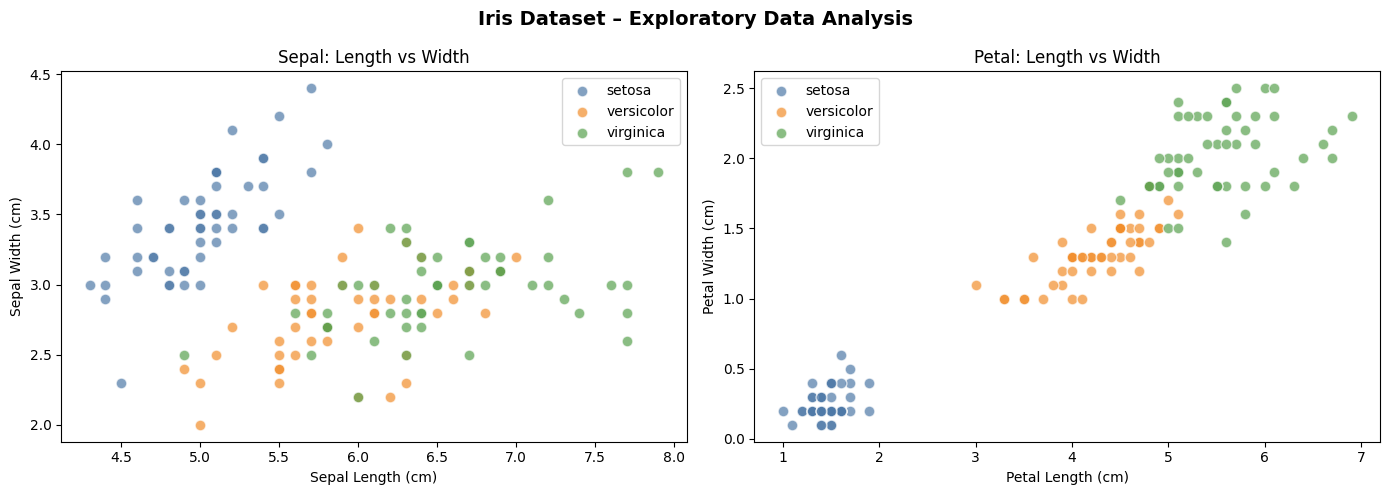

In [16]:
colors = {"setosa": "#4e79a7", "versicolor": "#f28e2b", "virginica": "#59a14f"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Iris Dataset – Exploratory Data Analysis", fontsize=14, fontweight="bold")

for species, grp in df.groupby("species"):
    axes[0].scatter(grp["sepal length (cm)"], grp["sepal width (cm)"],
                    label=species, color=colors[species], alpha=0.7, edgecolors="white", s=60)
axes[0].set_xlabel("Sepal Length (cm)"); axes[0].set_ylabel("Sepal Width (cm)")
axes[0].set_title("Sepal: Length vs Width"); axes[0].legend()

for species, grp in df.groupby("species"):
    axes[1].scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                    label=species, color=colors[species], alpha=0.7, edgecolors="white", s=60)
axes[1].set_xlabel("Petal Length (cm)"); axes[1].set_ylabel("Petal Width (cm)")
axes[1].set_title("Petal: Length vs Width"); axes[1].legend()

plt.tight_layout()
plt.show()


## Step 3 — Feature & Target Separation

- **X** = input features (the measurements)
- **y** = target labels (which species it is)


In [17]:
X = iris.data    # shape (150, 4)
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")
print(f"Unique labels          : {np.unique(y)} → {list(iris.target_names)}")


Feature matrix X shape : (150, 4)
Target vector  y shape : (150,)
Unique labels          : [0 1 2] → [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## Step 4 — Train-Test Split (80 / 20)

We split the data so the model is tested on data it has **never seen** during training.
`shuffle=True` randomises order to remove any ordering bias.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples : {len(X_train)}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing  samples : {len(X_test)}   ({len(X_test)/len(X)*100:.0f}%)")


Training samples : 120  (80%)
Testing  samples : 30   (20%)


## Step 5 — Feature Scaling (StandardScaler)

KNN calculates **Euclidean distance** between points.  
Without scaling, features with larger ranges dominate the distance unfairly.

`StandardScaler` converts each feature to **mean = 0, variance = 1**.

>  **Important rule:** Fit the scaler on training data only, then apply it to test data. Never fit on test data — that would be data leakage.


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Before scaling — first training sample:")
print(f"  {X_train[0]}")
print("After scaling — same sample:")
print(f"  {X_train_scaled[0].round(3)}")
print()
print(f"Scaled train mean (should be ~0): {X_train_scaled.mean(axis=0).round(3)}")
print(f"Scaled train std  (should be ~1): {X_train_scaled.std(axis=0).round(3)}")


Before scaling — first training sample:
  [4.6 3.6 1.  0.2]
After scaling — same sample:
  [-1.474  1.204 -1.563 -1.313]

Scaled train mean (should be ~0): [ 0. -0. -0. -0.]
Scaled train std  (should be ~1): [1. 1. 1. 1.]


## Step 6 — Finding the Best K (Elbow Method)

- **K=1** → overfitting (memorises training data, sensitive to noise)
- **K=100** → underfitting (too generic, ignores local patterns)
- **Optimal K** → the "elbow" where test accuracy is highest


In [20]:
from sklearn.neighbors import KNeighborsClassifier

k_range = range(1, 21)
train_accuracies = []
test_accuracies  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_accuracies.append(knn.score(X_train_scaled, y_train))
    test_accuracies.append(knn.score(X_test_scaled, y_test))

best_k = list(k_range)[test_accuracies.index(max(test_accuracies))]

print(f"✅ Best K = {best_k}  →  Test Accuracy = {max(test_accuracies)*100:.1f}%")

✅ Best K = 1  →  Test Accuracy = 100.0%


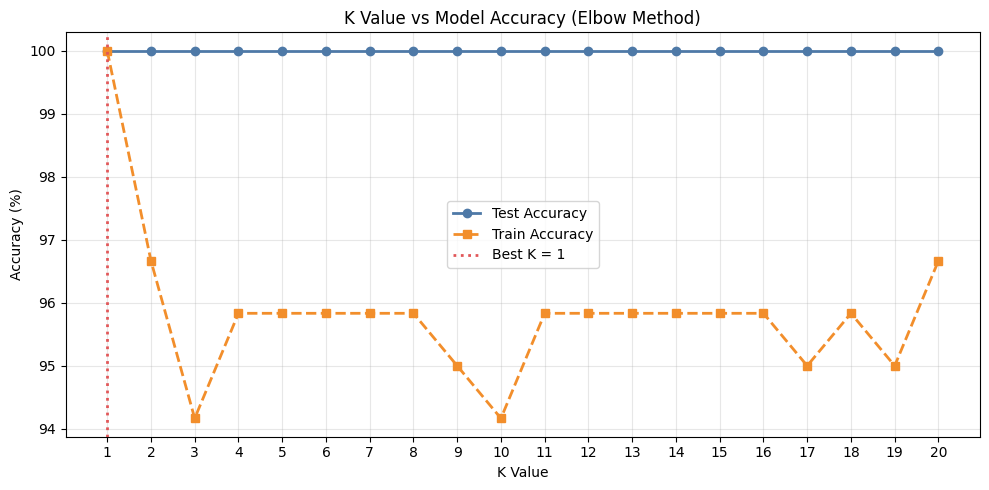

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, [a*100 for a in test_accuracies],
         "o-", color="#4e79a7", linewidth=2, markersize=6, label="Test Accuracy")
plt.plot(k_range, [a*100 for a in train_accuracies],
         "s--", color="#f28e2b", linewidth=2, markersize=6, label="Train Accuracy")
plt.axvline(x=best_k, color="#e15759", linestyle=":", linewidth=2, label=f"Best K = {best_k}")
plt.xlabel("K Value"); plt.ylabel("Accuracy (%)")
plt.title("K Value vs Model Accuracy (Elbow Method)")
plt.legend(); plt.xticks(list(k_range)); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Step 7 — Train Final KNN Model

Three lines are all it takes with scikit-learn:
1. **Instantiate** — build the model frame
2. **Fit** — memorise the training map
3. **Predict** — apply the learned logic


In [22]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f"Model trained with K = {best_k}")
print(f"Predictions made on {len(y_test)} test samples")


Model trained with K = 1
Predictions made on 30 test samples


## Step 8 — Prediction Preview (First 10 Samples)

In [23]:
comparison = pd.DataFrame({
    "Actual"   : [iris.target_names[i] for i in y_test],
    "Predicted": [iris.target_names[i] for i in y_pred],
    "Match?"   : ["✓ Correct" if a == p else "✗ Wrong"
                  for a, p in zip(y_test, y_pred)],
})
comparison.head(10)


,Actual,Predicted,Match?
0,versicolor,versicolor,✓ Correct
1,setosa,setosa,✓ Correct
2,virginica,virginica,✓ Correct
3,versicolor,versicolor,✓ Correct
4,versicolor,versicolor,✓ Correct
5,setosa,setosa,✓ Correct
6,versicolor,versicolor,✓ Correct
7,virginica,virginica,✓ Correct
8,versicolor,versicolor,✓ Correct
9,versicolor,versicolor,✓ Correct


## Step 9 — Evaluation Metrics

### Why not just accuracy?
On imbalanced datasets, a model that always predicts the majority class can look 99% accurate — the **"Accuracy Mirage"** (as shown in the PDF).

**F1 Score** = harmonic mean of Precision & Recall — a more honest metric.


In [24]:
accuracy = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred, average="weighted")

print(f"{'='*40}")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  F1 Score  : {f1:.4f}")
print(f"{'='*40}")
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


  Accuracy  : 100.00%
  F1 Score  : 1.0000

Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 10 — Confusion Matrix

The confusion matrix shows exactly which classes are confused with each other:

| Cell | Meaning |
|---|---|
| **TP** | Correctly classified (diagonal) |
| **FP** | Predicted positive, actually negative (False Alarm / Type I) |
| **FN** | Predicted negative, actually positive (Missed / Type II) |
| **TN** | Correctly classified as negative |


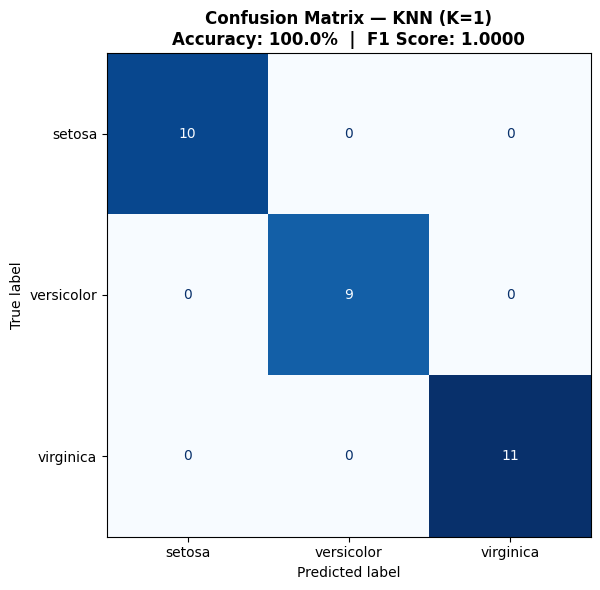

In [25]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(
    f"Confusion Matrix — KNN (K={best_k})\nAccuracy: {accuracy*100:.1f}%  |  F1 Score: {f1:.4f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


## Step 11 — Final Summary Dashboard

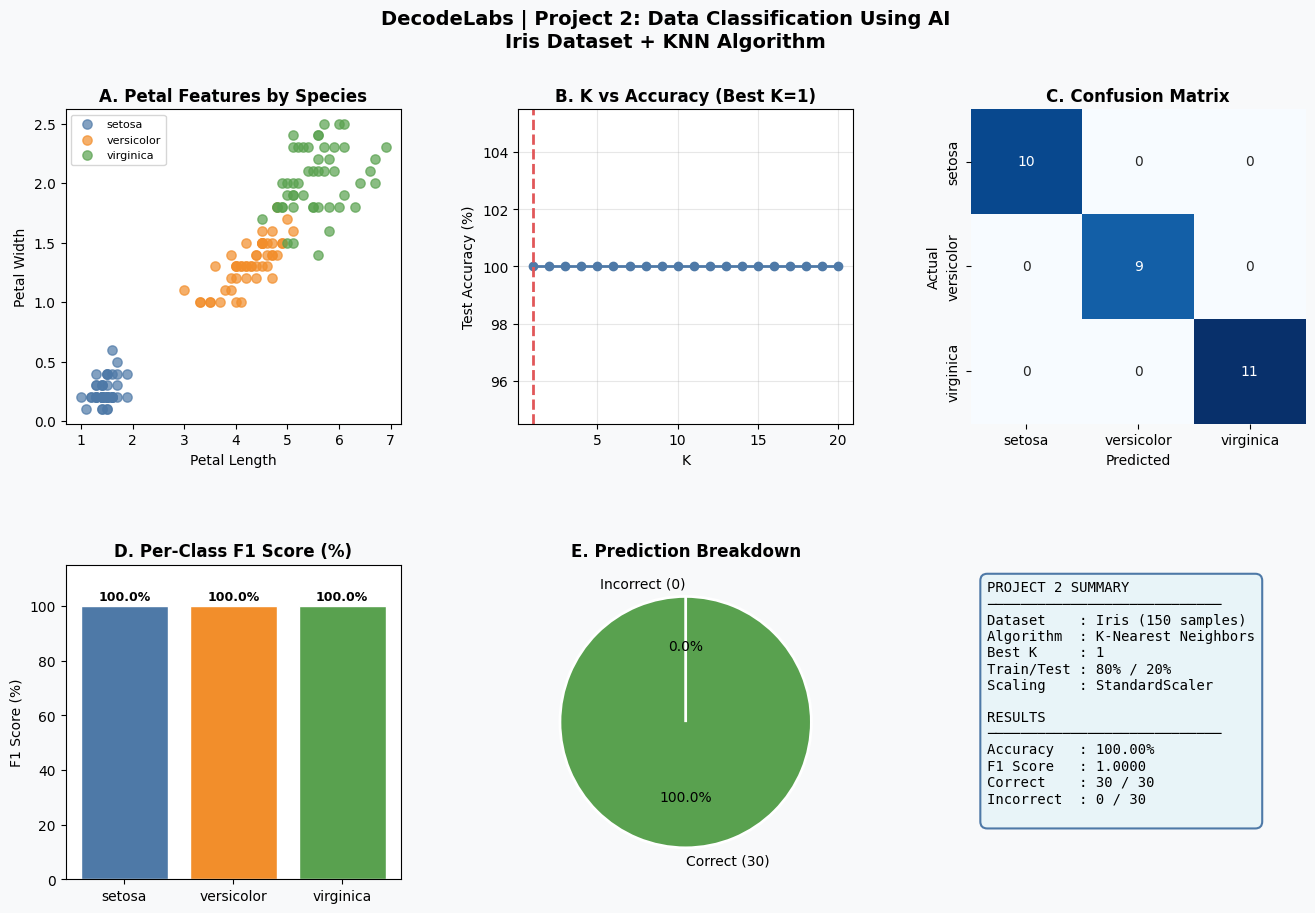

In [26]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#f8f9fa")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# A: Scatter
ax_a = fig.add_subplot(gs[0, 0])
for species, grp in df.groupby("species"):
    ax_a.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                 label=species, color=colors[species], alpha=0.7, s=45)
ax_a.set_title("A. Petal Features by Species", fontweight="bold")
ax_a.set_xlabel("Petal Length"); ax_a.set_ylabel("Petal Width")
ax_a.legend(fontsize=8)

# B: K vs Accuracy
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(k_range, [a*100 for a in test_accuracies], "o-", color="#4e79a7", linewidth=2)
ax_b.axvline(x=best_k, color="#e15759", linestyle="--", linewidth=2)
ax_b.set_title(f"B. K vs Accuracy (Best K={best_k})", fontweight="bold")
ax_b.set_xlabel("K"); ax_b.set_ylabel("Test Accuracy (%)"); ax_b.grid(True, alpha=0.3)

# C: Confusion Matrix
ax_c = fig.add_subplot(gs[0, 2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            ax=ax_c, cbar=False)
ax_c.set_title("C. Confusion Matrix", fontweight="bold")
ax_c.set_xlabel("Predicted"); ax_c.set_ylabel("Actual")

# D: Per-class F1
ax_d = fig.add_subplot(gs[1, 0])
per_class_f1 = f1_score(y_test, y_pred, average=None)
bars = ax_d.bar(iris.target_names, per_class_f1 * 100,
                color=["#4e79a7", "#f28e2b", "#59a14f"], edgecolor="white")
ax_d.set_ylim(0, 115); ax_d.set_title("D. Per-Class F1 Score (%)", fontweight="bold")
ax_d.set_ylabel("F1 Score (%)")
for bar, val in zip(bars, per_class_f1):
    ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# E: Pie chart
ax_e = fig.add_subplot(gs[1, 1])
correct = int(np.sum(y_pred == y_test))
incorrect = int(np.sum(y_pred != y_test))
ax_e.pie([correct, incorrect],
         labels=[f"Correct ({correct})", f"Incorrect ({incorrect})"],
         colors=["#59a14f", "#e15759"],
         autopct="%1.1f%%", startangle=90,
         wedgeprops={"edgecolor": "white", "linewidth": 2})
ax_e.set_title("E. Prediction Breakdown", fontweight="bold")

# F: Text summary
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis("off")
summary_text = (
    f"PROJECT 2 SUMMARY\n"
    f"{'─'*28}\n"
    f"Dataset    : Iris (150 samples)\n"
    f"Algorithm  : K-Nearest Neighbors\n"
    f"Best K     : {best_k}\n"
    f"Train/Test : 80% / 20%\n"
    f"Scaling    : StandardScaler\n\n"
    f"RESULTS\n"
    f"{'─'*28}\n"
    f"Accuracy   : {accuracy*100:.2f}%\n"
    f"F1 Score   : {f1:.4f}\n"
    f"Correct    : {correct} / {len(y_test)}\n"
    f"Incorrect  : {incorrect} / {len(y_test)}\n"
)
ax_f.text(0.05, 0.95, summary_text, transform=ax_f.transAxes,
          fontsize=10, verticalalignment="top", fontfamily="monospace",
          bbox=dict(boxstyle="round,pad=0.5", facecolor="#e8f4f8",
                    edgecolor="#4e79a7", linewidth=1.5))

fig.suptitle("DecodeLabs | Project 2: Data Classification Using AI\nIris Dataset + KNN Algorithm",
             fontsize=14, fontweight="bold", y=0.98)
plt.show()


##  Final Conclusion

This project successfully demonstrated a complete **supervised learning pipeline** using the Iris dataset and the K-Nearest Neighbors algorithm.

### Pipeline Steps Completed:
1. Loaded and explored the Iris dataset (150 samples, 3 classes, 4 features)
2. Separated features (X) from target labels (y)
3. Split data **80/20** into training and test sets with shuffle
4. Applied **StandardScaler** to eliminate feature scale bias
5. Tested **K values 1–20** using the elbow method to find optimal K
6. Trained the final KNN model and made predictions
7. Validated using **Accuracy**, **Confusion Matrix**, and **F1 Score**

### Key Insight:
> In supervised learning, we do not write rules manually.  
> We provide labelled history, and the machine derives the logic.  
> — *DecodeLabs, Project 2 PDF*

### Why it works :
The Iris dataset has clean, well-separated clusters — especially in petal measurements. With proper scaling, KNN finds the decision boundaries naturally without any manual rules.

---
*Built as part of the DecodeLabs Industrial Training Program | Batch 2026*
